Libraries

In [5]:
! pip install brian2

   ---------------------------------------- 0.0/1.1 MB ? eta -:--:--
   ------------------- -------------------- 0.5/1.1 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 1.1/1.1 MB 7.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 31.5 MB/s eta 0:00:00

   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   -------------------------- ------------- 2/3 [brian2]
   -------------------------- ------------- 2/3 [brian2]
   -------------------------- ------------- 2/3 [brian2]
   ---------------------------------------- 3/3 [brian2]




[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import brian2
from brian2 import *

import numpy as np
import matplotlib.pyplot as plt

# Задание

Параметры, задание нейрона и синапсов

In [60]:
from brian2 import *

start_scope()

tau_m = 10*ms #RC мембранная постоянная времени
v_rest = -70*mV
v_reset = -65*mV
v_threshold = -50*mV
t_ref = 2*ms

eqs = '''
dv/dt = (v_rest - v)/tau_m : volt (unless refractory)
'''
#тело нейрона
neuron = NeuronGroup(
    1, eqs, 
    threshold='v > v_threshold',
    reset='v = v_reset', 
    refractory=t_ref, 
    method='exact'
    )
neuron.v = v_rest

#пуассоновская последовательность
N = 100
rate = 15*Hz
P_group = PoissonGroup(N, rates=rate)

#синапсы
w = 1.0*mV

syn = Synapses(P_group, neuron, on_pre='v_post += w')
syn.connect()

Запуск

In [61]:
mon_v = StateMonitor(neuron, 'v', record=True)
spikes_postsyn = SpikeMonitor(neuron)
spikes_presyn = SpikeMonitor(P_group)

run(1000*ms)

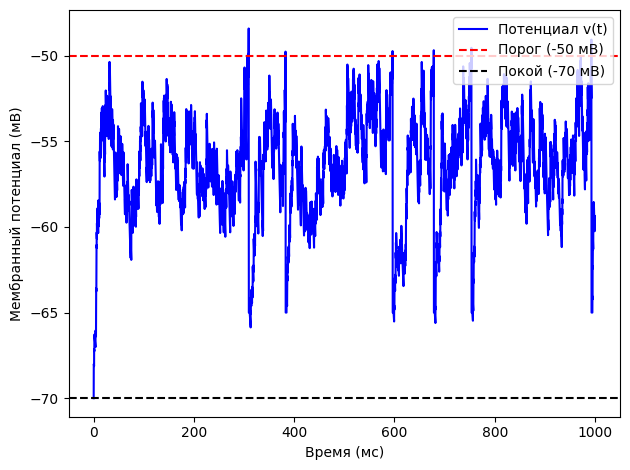

In [62]:
# мембранный потенциал постсинаптического нейрона
plt.plot(mon_v.t/ms, mon_v.v[0]/mV, label='Потенциал v(t)', color='blue')
plt.axhline(v_threshold/mV, color='red', linestyle='--', label='Порог (-50 мВ)')
plt.axhline(v_rest/mV, color='black', linestyle='--', label='Покой (-70 мВ)')
plt.xlabel('Время (мс)')
plt.ylabel('Мембранный потенциал (мВ)')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

Получение зависимости средней частоты выходных спайков нейрона от средней частоты входных спайков

In [73]:
input_rates = [1*Hz, 3*Hz, 5*Hz, 7*Hz, 9*Hz, 10*Hz, 12*Hz, 15*Hz, 20*Hz, 25*Hz, 30*Hz, 35*Hz, 40*Hz, 45*Hz, 50*Hz, 60*Hz]
output_rates = []
run_time=2000*ms
tau_m = 10*ms #RC мембранная постоянная времени
v_rest = -70*mV
v_reset = -65*mV
v_threshold = -50*mV
t_ref = 2*ms

eqs = '''
dv/dt = (v_rest - v)/tau_m : volt (unless refractory)
'''

for i in input_rates:
    start_scope()

    #тело нейрона
    neuron = NeuronGroup(
    1, eqs, 
    threshold='v > v_threshold',
    reset='v = v_reset', 
    refractory=t_ref, 
    method='exact'
    )
    neuron.v = v_rest

    #пуассоновская последовательность
    N = 100
    P_group = PoissonGroup(N, rates=i)

    #синапсы
    w = 1.0*mV
    syn = Synapses(P_group, neuron, on_pre='v_post += w')
    syn.connect()

    spikes = SpikeMonitor(neuron)

    run(run_time)

    rate_med = spikes.num_spikes / run_time
    output_rates.append(rate_med / Hz)


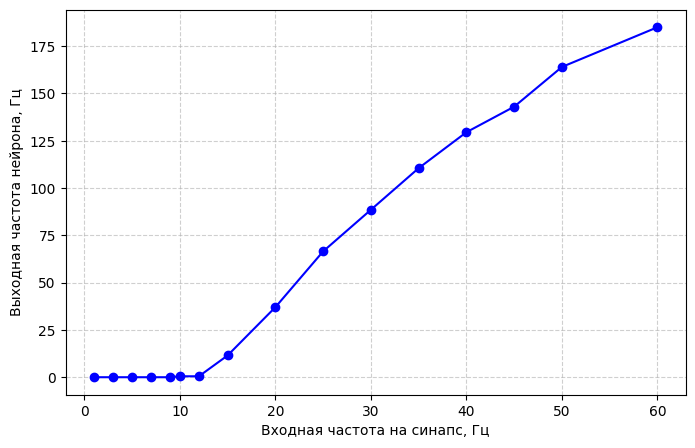

In [ ]:

plt.figure(figsize=(8, 5))
plt.plot(input_rates / Hz, output_rates, 'o-', color='blue')
plt.xlabel('Входная частота на синапс, Гц')
plt.ylabel('Выходная частота нейрона, Гц')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Test

One neuron

Text(0, 0.5, 'v')

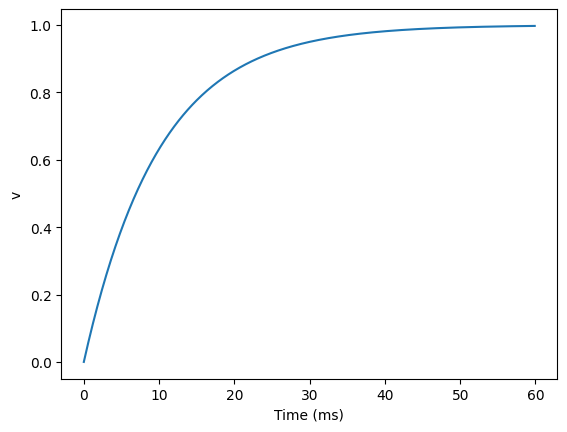

In [52]:
start_scope()
tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1
'''

G = NeuronGroup(1, eqs, method='exact')
M = StateMonitor(G, 'v', record=True)

run(60*ms)

plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')

Spike times: [21.9 49.9] ms


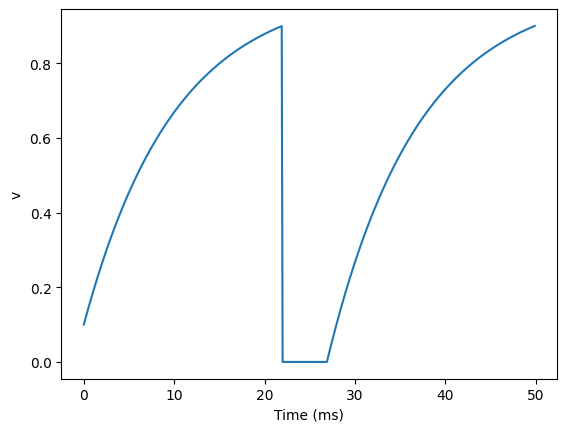

In [53]:
start_scope()

tau = 10*ms
eqs = '''
dv/dt = (1-v)/tau : 1 (unless refractory)
'''

G = NeuronGroup(1, eqs, threshold='v>0.9', reset='v = 0',refractory=5*ms, method='exact')
G.v = 0.1
M = StateMonitor(G, 'v', record=0)
spikemon = SpikeMonitor(G)
run(50*ms)
plot(M.t/ms, M.v[0])
xlabel('Time (ms)')
ylabel('v')

print('Spike times: %s' % spikemon.t[:])

Multiple neurons

Text(0, 0.5, 'Neuron index')

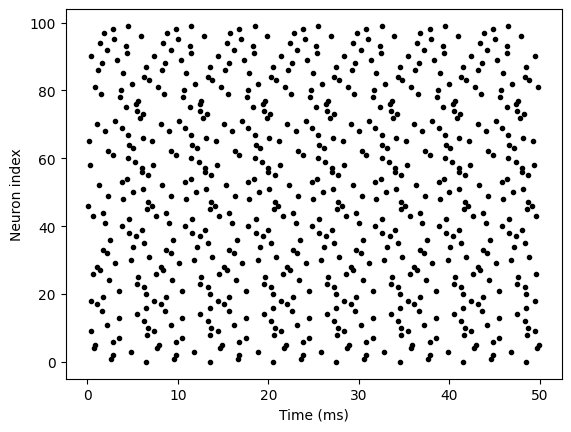

In [54]:
start_scope()

N = 100
tau = 10*ms
eqs = '''
dv/dt = (2-v)/tau : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', method='exact')
G.v = 'rand()'

spikemon = SpikeMonitor(G)

run(50*ms)

plot(spikemon.t/ms, spikemon.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')

Text(0, 0.5, 'Firing rate (sp/s)')

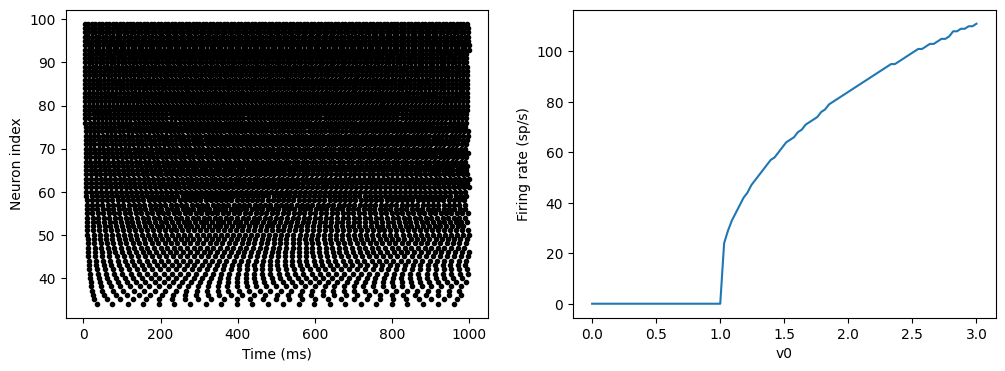

In [55]:
start_scope()

N = 100
tau = 10*ms
v0_max = 3.
duration = 1000*ms

eqs = '''
dv/dt = (v0-v)/tau : 1 (unless refractory)
v0 : 1
'''

G = NeuronGroup(N, eqs, threshold='v>1', reset='v=0', refractory=5*ms, method='exact')
M = SpikeMonitor(G)

G.v0 = 'i*v0_max/(N-1)'

run(duration)

figure(figsize=(12,4))
subplot(121)
plot(M.t/ms, M.i, '.k')
xlabel('Time (ms)')
ylabel('Neuron index')
subplot(122)
plot(G.v0, M.count/duration)
xlabel('v0')
ylabel('Firing rate (sp/s)')